# 01. EDA — 관찰에서 모델 전략으로

[Day 1 계획서](../docs/day1-plan.pdf)의 Q1~Q5를 원자료 캐시로 재현한다. 전체 수명 경로와 knee는 설명용이며 모델 입력에 사용하지 않는다. B3가 없는 경우 B1·B2만 분석한다.


In [1]:
# ── 공통 설정 ──────────────────────────────────────────────
import sys
from pathlib import Path

# notebooks/ 에서 실행해도 프로젝트 루트의 src 패키지를 import 할 수 있도록 경로 추가
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 설치된 한글 폰트가 있으면 사용하고, 그림의 영문 표기는 기본 폰트로도 표시한다.
from matplotlib import font_manager
fonts = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ("AppleGothic", "Malgun Gothic", "NanumGothic") if f in fonts), "DejaVu Sans")
sns.set_theme(style="whitegrid", font=font)
plt.rcParams["axes.unicode_minus"] = False

# 배치별 색상 (Day 1 산출물과 동일한 톤)
BATCH_COLOR = {"B1": "#2f6b9a", "B2": "#c77d2a", "B3": "#7f5aa6"}

from src.preprocess import load_cache
from src.features import build_features, delta_q

# cells   : 셀 메타정보 (batch, policy, cycle_life, last_QD ...)
# summary : 사이클별 요약 (QD, IR, 온도, 충전시간)
# qdlin   : {"셀ID|사이클인덱스": Qdlin 배열(1,000 전압점)}
cells, summary, qdlin = load_cache()

# 레이블(cycle_life) 보유 셀의 피처 테이블 — B1 46 / B2 39 / B3 44셀
feat = build_features()

# 배치별 셀 수 · 종료 근접(마지막 QD ≤ 0.885 Ah) 셀 수 · 수명 중앙값
feat.groupby("batch").agg(n=("cell_id", "size"), near_eol=("near_eol", "sum"),
                          life_median=("cycle_life", "median"))

,n,near_eol,life_median
batch,,,
B1,46,36,858.5
B2,39,39,472.0
B3,44,44,1005.5


## Q1. Cycle Life 분포
- B1에는 500 미만 셀이 없고, B2는 71.8%가 500 미만 → **B1에 없는 단수명 구간을 B2에서 평가**

In [2]:
# 배치별 수명 히스토그램 (세 배치 동일 구간 150~2,300)
fig, axes = plt.subplots(1, feat.batch.nunique(), figsize=(5 * feat.batch.nunique(), 3.8), sharey=True)
bins = np.arange(150, 2350, 150)
for ax, (b, g) in zip(axes, feat.groupby("batch")):
    ax.hist(g["cycle_life"], bins=bins, color=BATCH_COLOR[b], edgecolor="white")
    # 단수명(<500) · 장수명(>1,000) 기준선
    ax.axvline(500, color="tab:red", ls="--", lw=1); ax.axvline(1000, color="tab:green", ls="--", lw=1)
    ax.set_title(f"{b} · n={len(g)} · 중앙값 {g.cycle_life.median():.0f}"); ax.set_xlabel("cycle life")
axes[0].set_ylabel("셀 수"); plt.tight_layout(); plt.show()

# 단수명(<500) / 장수명(>1,000) 비율 (%)
feat.groupby("batch")["cycle_life"].agg(
    under_500=lambda s: (s < 500).mean() * 100, over_1000=lambda s: (s > 1000).mean() * 100).round(1)

<Figure size 1500x380 with 3 Axes>

,under_500,over_1000
batch,,
B1,0.0,21.7
B2,71.8,7.7
B3,0.0,52.3


### 배치별 가장 짧은 수명 셀

같은 정책의 동료 셀과 비교하며, 짧다는 이유만으로 테스트 셀을 삭제하지 않는다.


In [3]:
shortest = feat.loc[feat.groupby("batch").cycle_life.idxmin()]
shortest[["cell_id", "policy", "cycle_life", "log_var_dQ", "Tavg_mean", "IR_mean"]]


,cell_id,policy,cycle_life,log_var_dQ,Tavg_mean,IR_mean
20,B1_c20,5.4C(80%)-5.4C,534.0,-3.367237,32.152922,0.015210
65,B2_c19,6C(60%)-3C,392.0,-3.291958,32.770067,0.016718
112,B3_c28,3.7C(31%)-5.9C-newstructure,541.0,-3.451658,35.696888,0.013421


## Q2. 열화 곡선
- 급변(knee)은 예측 시점(100사이클) 이후에 나타남 → 전체 경로 기반 knee는 입력에서 제외
- 10→100사이클 감소 속도는 장·단수명 차이가 없고, 마지막 20% 구간에서 단수명 셀이 1.5~1.8배 빠름

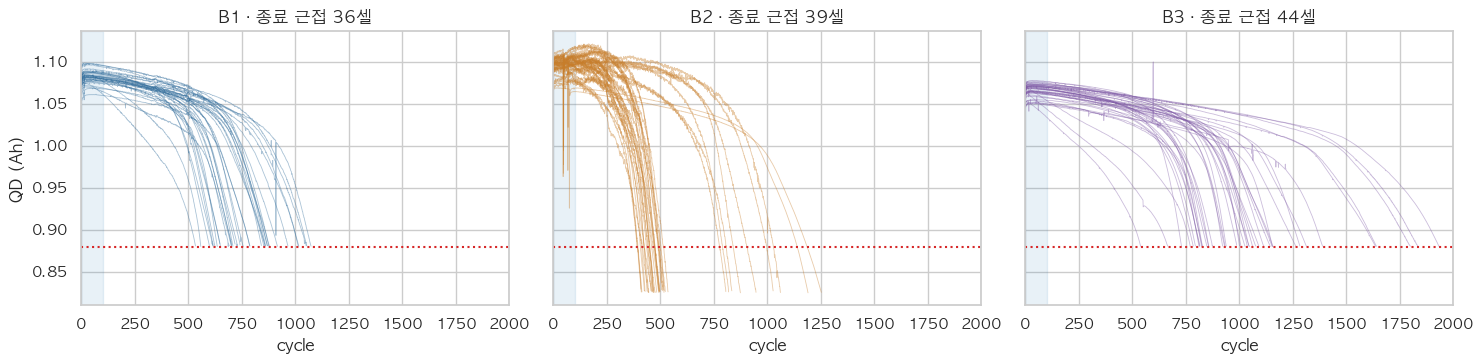

In [4]:
# 종료 근접 셀의 사이클별 방전용량(QD) 곡선
fig, axes = plt.subplots(1, feat.batch.nunique(), figsize=(5 * feat.batch.nunique(), 3.8), sharey=True)
use = feat[feat["near_eol"]]
for ax, (b, g) in zip(axes, use.groupby("batch")):
    for cid in g["cell_id"]:
        # 0.8~1.2 Ah 밖의 값은 측정 스파이크로 보고 그리지 않음
        s = summary[(summary.cell_id == cid) & summary.QD.between(0.8, 1.2)]
        ax.plot(s["cycle"], s["QD"], color=BATCH_COLOR[b], lw=0.6, alpha=0.4)
    ax.axvspan(0, 100, color="tab:blue", alpha=0.1)   # 모델 입력 구간 (초기 100사이클)
    ax.axhline(0.88, color="tab:red", ls=":")          # EOL = 공칭 1.1 Ah의 80%
    ax.set_title(f"{b} · 종료 근접 {len(g)}셀"); ax.set_xlabel("cycle"); ax.set_xlim(0, 2000)
axes[0].set_ylabel("QD (Ah)"); plt.tight_layout(); plt.show()

In [5]:
from src.eda import summarize

eda = summarize()
fade = eda["fades"]
rows = []
for b, g in fade.groupby("batch"):
    lo, hi = g.cycle_life.quantile([1/3, 2/3])
    for name, sub in [("수명 하위 1/3", g[g.cycle_life <= lo]), ("수명 상위 1/3", g[g.cycle_life >= hi])]:
        rows.append({"batch": b, "group": name, "n": len(sub), **sub[["early", "late"]].median().round(3)})
pd.DataFrame(rows)


{
  "batches": {
    "B1": {
      "n": 46,
      "near_eol": 36,
      "life_median": 858.5,
      "under_500_pct": 0.0,
      "over_1000_pct": 21.73913043478261,
      "early_fade_lower": 0.019714444444444514,
      "early_fade_upper": 0.008551111111111521,
      "late_fade_ratio": 1.4720026087140596,
      "knee_found": 36,
      "knee_median": 579.0,
      "max_time_gap_hours_median": 0.001409986111110717,
      "high_current_life_rho": -0.28992845745755835,
      "high_current_late_fade_rho": -0.07335907335907337
    },
    "B2": {
      "n": 39,
      "near_eol": 39,
      "life_median": 472.0,
      "under_500_pct": 71.7948717948718,
      "over_1000_pct": 7.6923076923076925,
      "early_fade_lower": -0.012423888888888098,
      "early_fade_upper": 0.014120000000001416,
      "late_fade_ratio": 1.795243813931928,
      "knee_found": 39,
      "knee_median": 361.0,
      "max_time_gap_hours_median": 65.3546717777778,
      "high_current_life_rho": 0.05314303094338464,
      "hig

,batch,group,n,early,late
0,B1,수명 하위 1/3,12,0.020,1.004
1,B1,수명 상위 1/3,12,0.009,0.682
2,B2,수명 하위 1/3,14,-0.012,2.290
3,B2,수명 상위 1/3,13,0.014,1.275
4,B3,수명 하위 1/3,15,0.012,0.752
5,B3,수명 상위 1/3,15,0.016,0.472


### Knee 탐색과 데이터 품질

100사이클 이후 경로를 7점 중앙값으로 평활하고 두 직선을 탐색한다. SSE가 20% 이상 줄고 후반 감소 기울기가 1.5배 이상 클 때 탐색 knee로 표시한다. 이후의 정보를 사용하므로 예측 입력에서 제외한다.


In [6]:
pd.DataFrame(eda["stats"]["batches"]).T[["knee_found", "knee_median", "max_time_gap_hours_median"]].round(2)


,knee_found,knee_median,max_time_gap_hours_median
B1,36.0,579.0,0.00
B2,39.0,361.0,65.35
B3,44.0,827.0,0.00


## Q3. ΔQ(V) = Q100(V) − Q10(V)
- 수명 하위 1/3의 전압별 변화가 더 큼 → 분산으로 불균일성을 요약 (`log10 var(ΔQ)`)

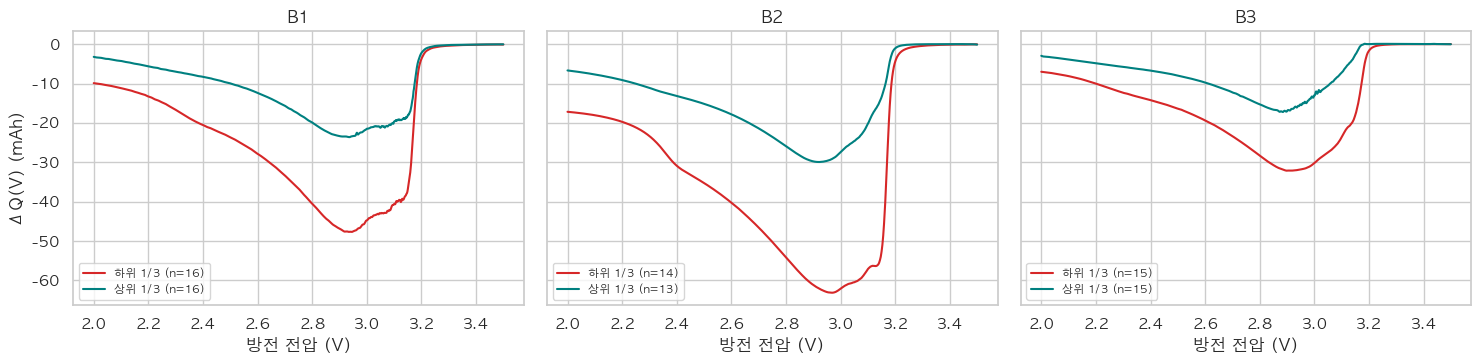

In [7]:
# 원자료 Vdlin: 3.5V → 2.0V, 1,000점. 임의의 전압축을 만들지 않는다.
fig, axes = plt.subplots(1, feat.batch.nunique(), figsize=(5 * feat.batch.nunique(), 3.8), sharey=True)
for ax, (b, g) in zip(axes, feat.groupby("batch")):
    # 배치 안에서 수명 하위 1/3 vs 상위 1/3
    lo, hi = g["cycle_life"].quantile([1/3, 2/3])
    for name, sub, color in [("하위 1/3", g[g.cycle_life <= lo], "tab:red"), ("상위 1/3", g[g.cycle_life >= hi], "teal")]:
        # 셀별 ΔQ(V) 곡선(mAh)을 쌓아 평균 곡선을 그림
        curves = np.stack([delta_q(qdlin, c) * 1000 for c in sub["cell_id"]])
        ax.plot(qdlin[f"voltage|{b}"], curves.mean(0), color=color, label=f"{name} (n={len(sub)})")
    ax.set_title(b); ax.set_xlabel("방전 전압 (V)"); ax.legend(fontsize=8)
axes[0].set_ylabel("ΔQ(V) (mAh)"); plt.tight_layout(); plt.show()

## Q4. 충전 정책·실제 전류 패턴과 수명

충전 조건을 후보로 검토하되, 정책 내부 관계와 배치 차이를 함께 확인한다. 고전류 시간 비율은 배치마다 수명과의 관계가 달라 모델 입력에서 보류한다.


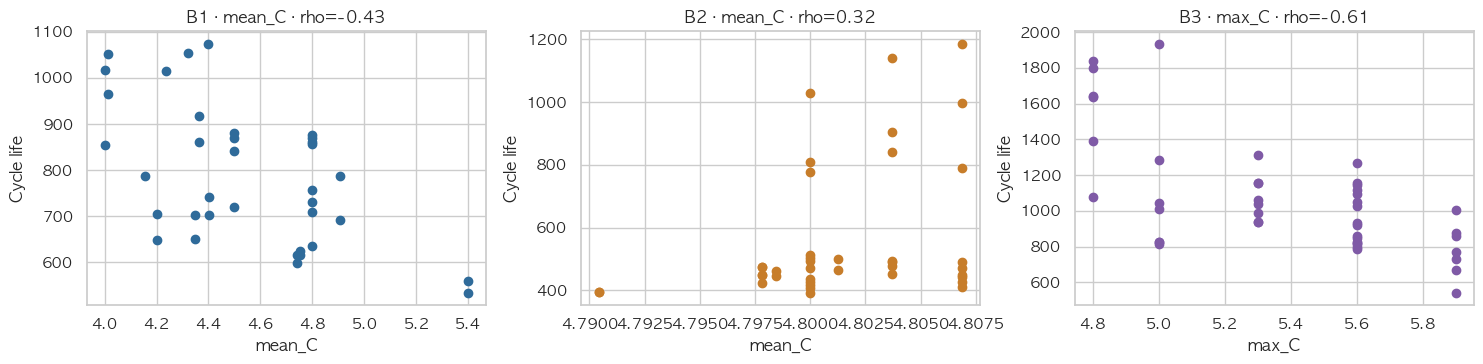

n  life_mean
batch group                     
B1    standard      2      753.0
B2    newstructure  3      871.7
      standard      5      483.6
B3    newstructure  6     1564.2

In [8]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, feat.batch.nunique(), figsize=(5 * feat.batch.nunique(), 3.8))
for ax, (b, d) in zip(axes, feat.groupby("batch")):
    d = d[d.near_eol]
    x = "max_C" if b == "B3" else "mean_C"
    ax.scatter(d[x], d.cycle_life, color=BATCH_COLOR[b])
    ax.set_title(f"{b} · {x} · rho={spearmanr(d[x], d.cycle_life)[0]:.2f}")
    ax.set_xlabel(x); ax.set_ylabel("Cycle life")
plt.tight_layout(); plt.show()

# 같은 충전 정책에서도 배치·실험집단에 따라 수명이 다르다.
feat[feat.policy_key == "4.8C(80%)-4.8C"].groupby(["batch", "group"]).agg(
    n=("cell_id", "size"), life_mean=("cycle_life", "mean")).round(1)


### 실제 전류 패턴과 열화 속도

cycle 10의 첫 방전 전까지 양의 전류가 흐르는 시간 중 저장 전류 > 4.2인 비율을 계산한다. 1분 이상 기록 간격은 제외한다. 이 값은 EDA 전용이다.


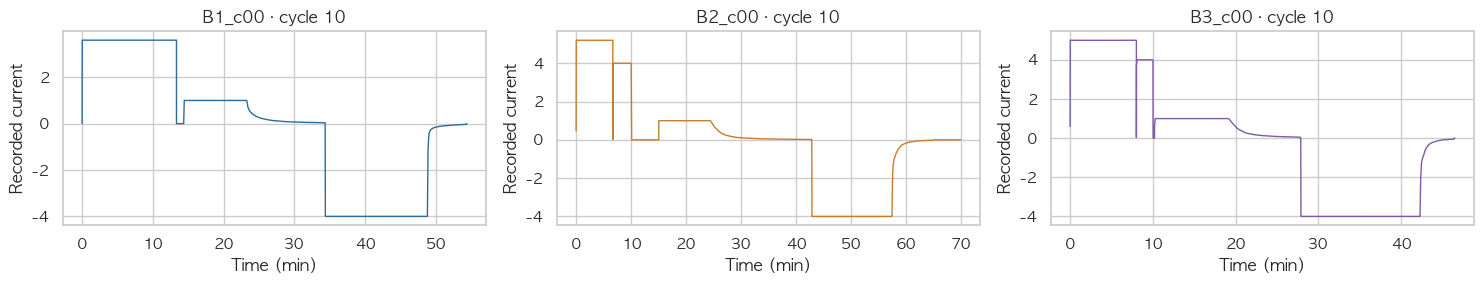

,high_current_life_rho,high_current_late_fade_rho
B1,-0.29,-0.07
B2,0.05,-0.21
B3,0.40,-0.24


In [9]:
fig, axes = plt.subplots(1, feat.batch.nunique(), figsize=(5 * feat.batch.nunique(), 3))
for ax, (b, g) in zip(axes, feat.groupby("batch")):
    cid = g.cell_id.iloc[0]
    ax.plot(qdlin[f"time|{cid}|9"], qdlin[f"current|{cid}|9"], color=BATCH_COLOR[b], lw=1)
    ax.set_title(f"{cid} · cycle 10"); ax.set_xlabel("Time (min)"); ax.set_ylabel("Recorded current")
plt.tight_layout(); plt.show()
pd.DataFrame(eda["stats"]["batches"]).T[["high_current_life_rho", "high_current_late_fade_rho"]].round(2)


## Q5. 상관관계와 중복

ΔQ 통계의 큰 상관은 피처 후보를 좁히는 근거다. 분산·평균·최솟값의 관계가 중복되므로 분산 하나부터 비교하며, 정책 평균을 제거한 뒤의 관계도 확인한다.


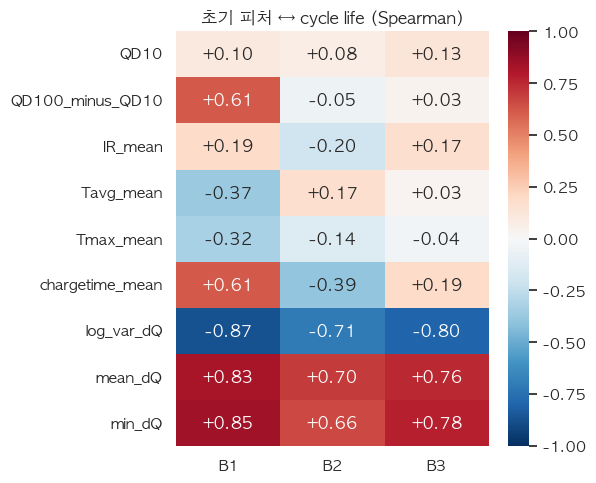

In [10]:
# 초기 사이클 피처 후보 (summary 통계 + ΔQ 통계)
cols = ["QD10", "QD100_minus_QD10", "IR_mean", "Tavg_mean", "Tmax_mean", "chargetime_mean",
        "log_var_dQ", "mean_dQ", "min_dQ"]

# 배치별로 각 피처 ↔ cycle life Spearman 상관 (IR 0값 등 결측은 제외)
corr = pd.DataFrame({b: [spearmanr(g[c], g.cycle_life, nan_policy="omit")[0] for c in cols]
                     for b, g in feat.groupby("batch")}, index=cols)

plt.figure(figsize=(6, 5)); sns.heatmap(corr, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("초기 피처 ↔ cycle life (Spearman)"); plt.tight_layout(); plt.show()